In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("Processed Datasets/DER Data.csv")

In [10]:
COLS = [
    "PV_system_size_DC",
    "total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers",
    "plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw",
]

In [11]:
# -----------------------
# 0) Decide how to treat missing
# -----------------------
def make_plot_df(df, fill_missing_with_zero: bool):
    """Create a plotting-friendly copy of the ZIP-level panel.

    This helper selects the plotting columns, coerces them to numeric, and
    optionally interprets missing values as "no assets in this ZIP" by filling
    NaNs with 0. Use `fill_missing_with_zero=True` for capacity/count variables
    that are missing only because a left-join found no matching records.

    Args:
        df: Input DataFrame containing at least `zip_code` and the columns in COLS.
        fill_missing_with_zero: If True, fill NaNs in COLS with 0.0.

    Returns:
        A new DataFrame with columns ['zip_code'] + COLS, with COLS numeric.
    """
    d = df[["zip_code"] + COLS].copy()
    for c in COLS:

        d[c] = pd.to_numeric(d[c], errors="coerce")
    if fill_missing_with_zero:
        d[COLS] = d[COLS].fillna(0.0)
    return d

df_raw = make_plot_df(df, fill_missing_with_zero=False)
df0    = make_plot_df(df, fill_missing_with_zero=True)   # often useful for totals/capacity

PV_system_size_DC      0.000000
total_chargers         0.450140
level1_chargers        0.450140
level2_chargers        0.450140
dc_fast_chargers       0.450140
plant_capacity_mw      0.943616
storage_capacity_mw    0.278192
wind_capacity_mw       0.980895
dtype: float64


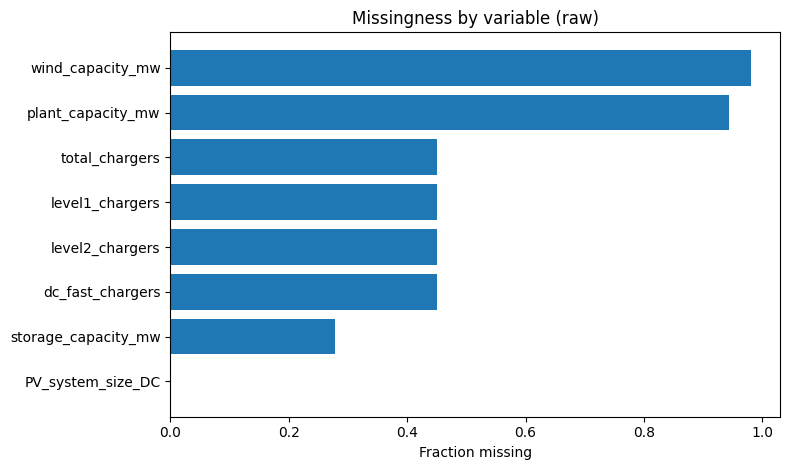

In [12]:
# -----------------------
# 1) Missingness bar (helps you justify assumptions)
# -----------------------
def plot_missingness(d, title):
    """Plot fraction-missing for each variable in COLS.

    Intended to diagnose whether NaNs represent true missing data versus
    "no matching records" after merging datasets. Also prints the missingness
    rates to the console for quick inspection.

    Args:
        d: DataFrame containing columns in COLS.
        title: Plot title.

    Returns:
        None. Displays a horizontal bar chart.
    """
    print(d[COLS].isna().mean())
    miss = d[COLS].isna().mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 0.35*len(COLS) + 2))
    plt.barh(miss.index, miss.values)
    plt.gca().invert_yaxis()
    plt.xlabel("Fraction missing")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_missingness(df_raw, "Missingness by variable (raw)")

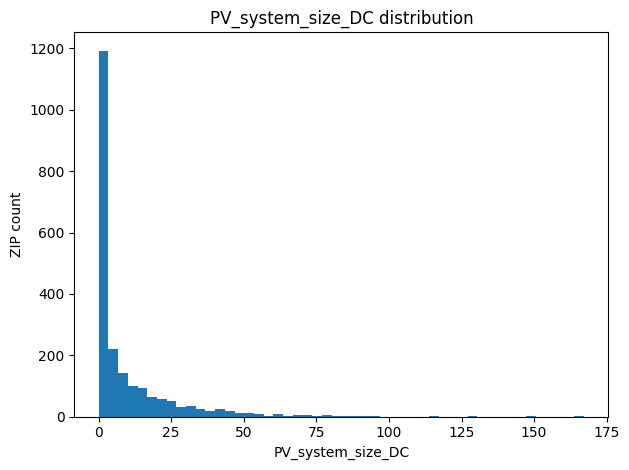

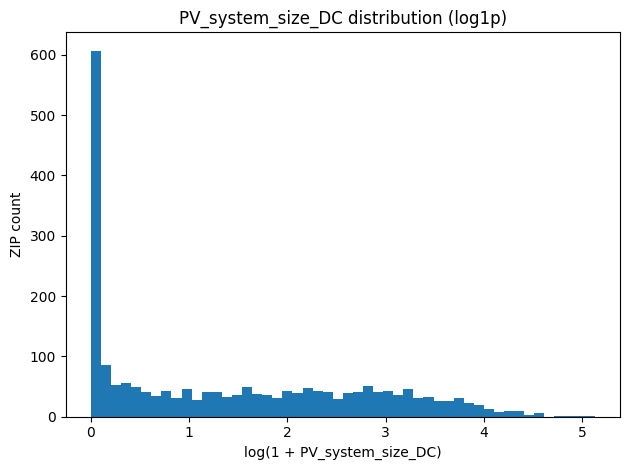

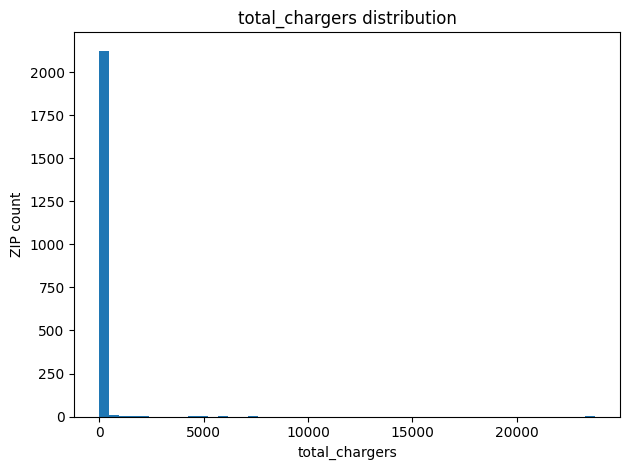

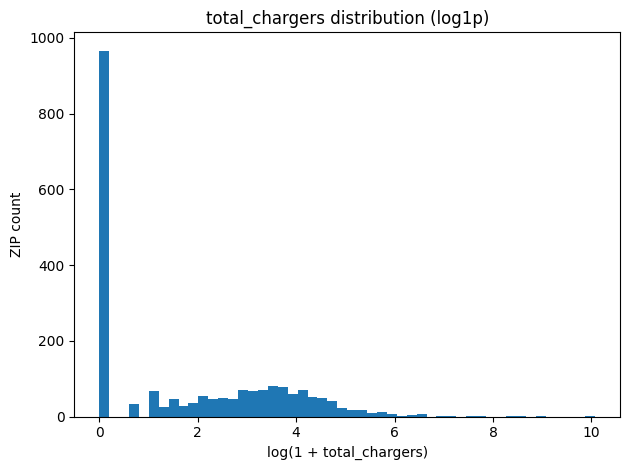

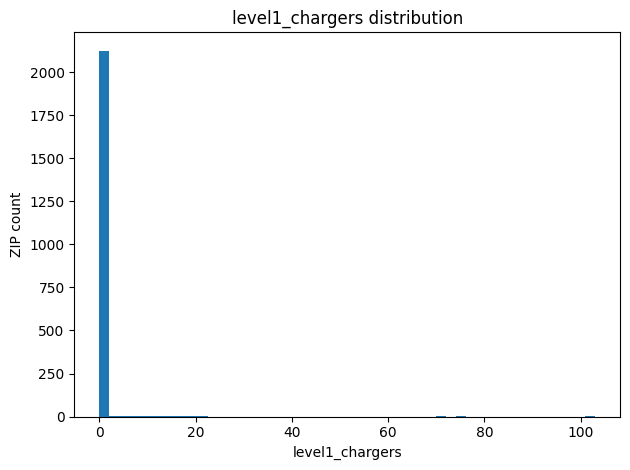

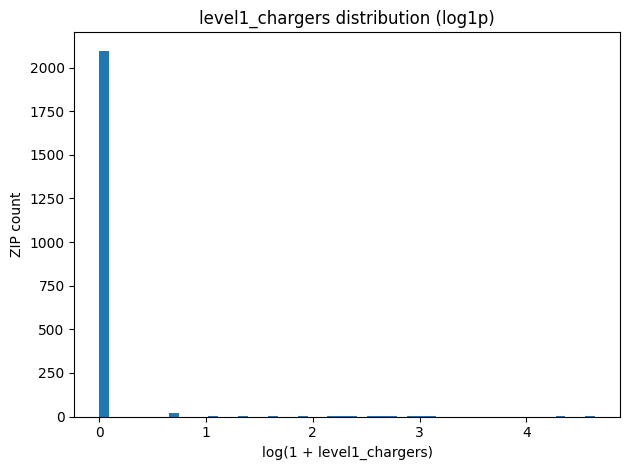

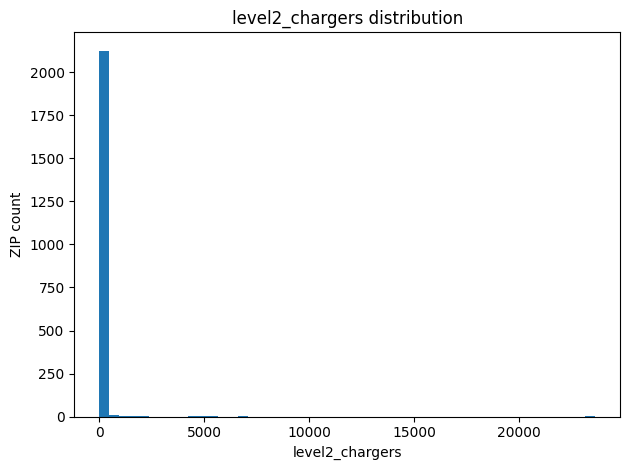

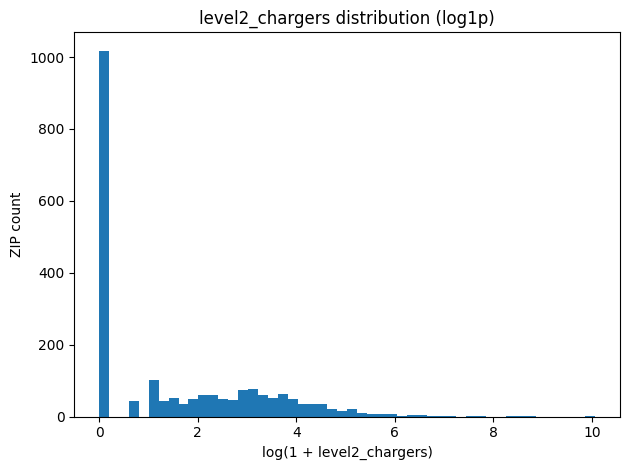

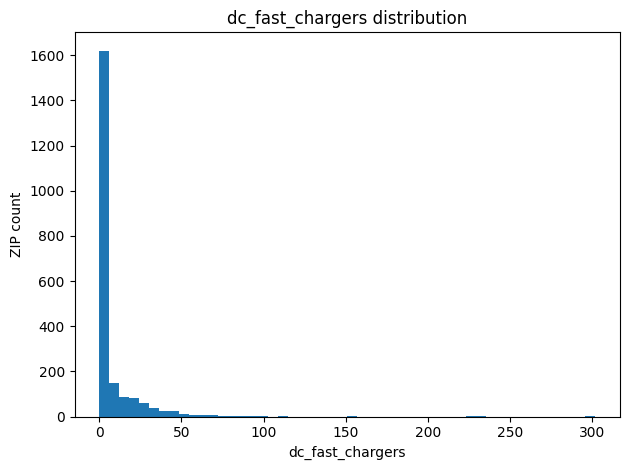

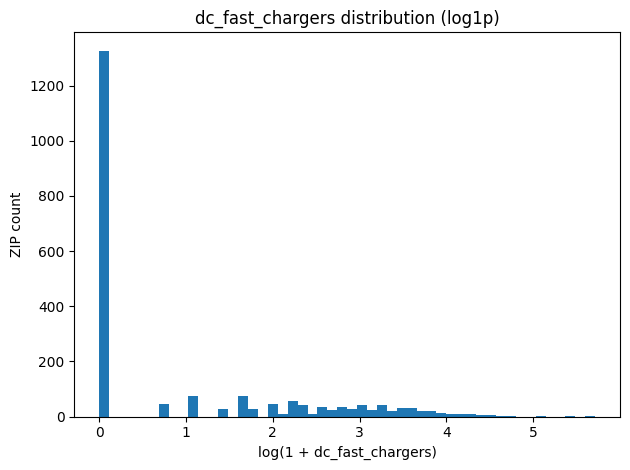

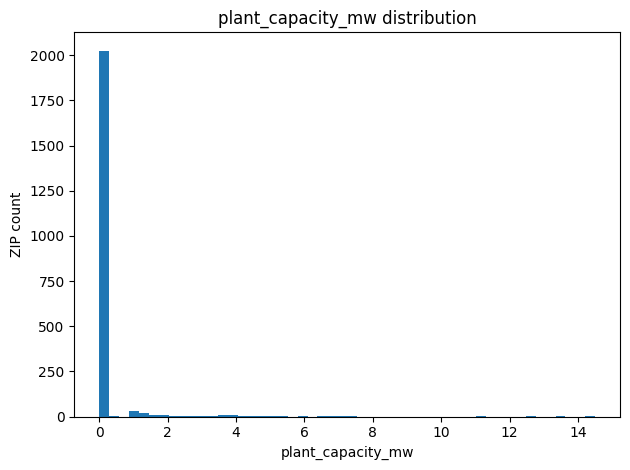

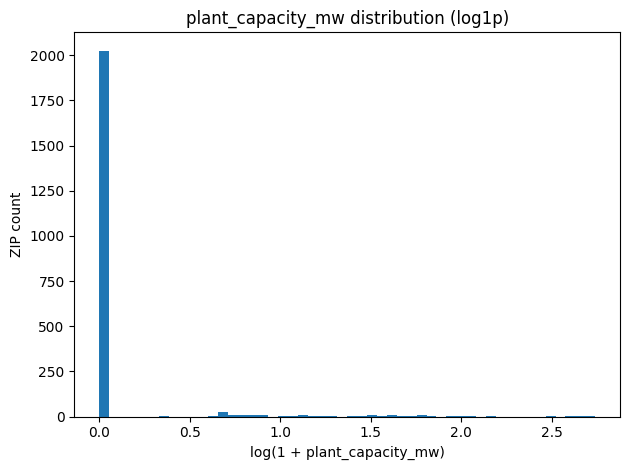

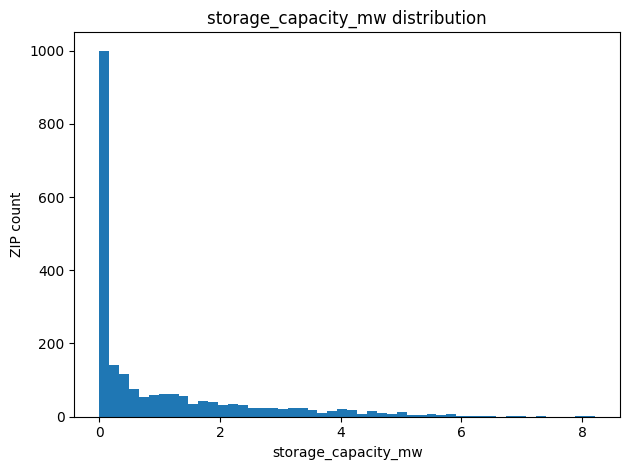

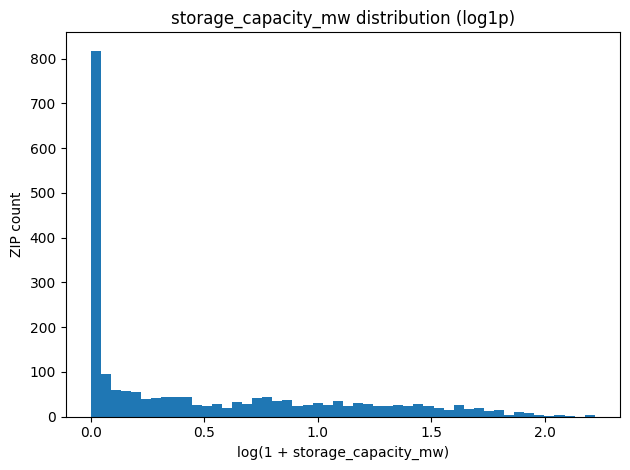

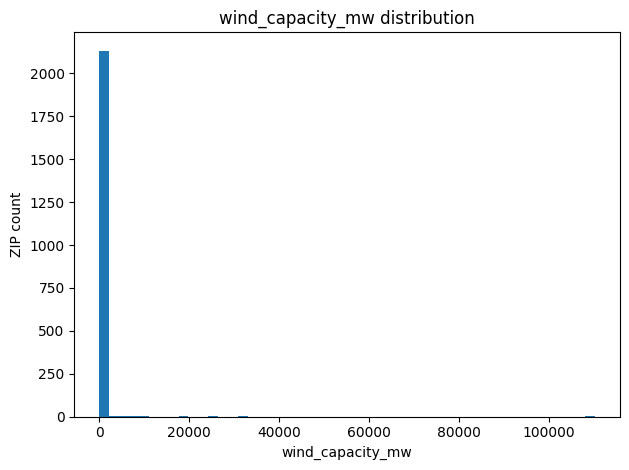

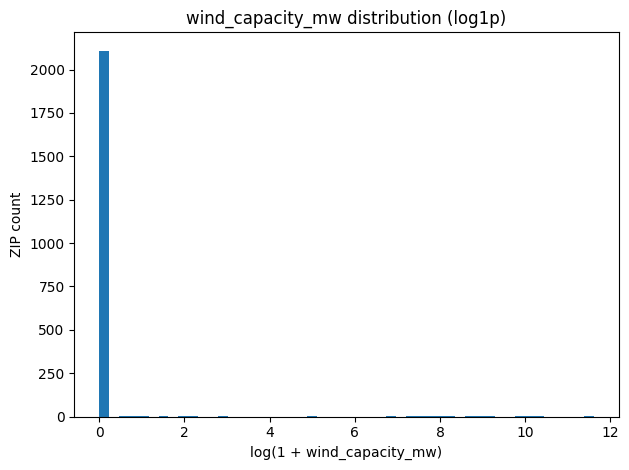

In [13]:
# -----------------------
# 2) Distributions: hist + log1p-hist
# -----------------------
def plot_hist(d, col, log1p=False, bins=50):
    """Plot a histogram for a single column, optionally using a log1p transform.

    Use `log1p=True` to make heavy-tailed, zero-heavy capacity/count variables
    easier to visualize. The transform used is log(1 + max(x, 0)) to avoid issues
    with small negative artifacts.

    Args:
        d: DataFrame containing `col`.
        col: Column name to plot.
        log1p: If True, plot log(1 + clipped_nonnegative(col)).
        bins: Number of histogram bins.

    Returns:
        None. Displays the histogram.
    """
    s = d[col].dropna().astype(float)
    if log1p:
        s = np.log1p(np.clip(s, 0, None))
        xlabel = f"log(1 + {col})"
        title  = f"{col} distribution (log1p)"
    else:
        xlabel = col
        title  = f"{col} distribution"
    plt.figure()
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("ZIP count")
    plt.tight_layout()
    plt.show()

for c in COLS:
    plot_hist(df0, c, log1p=False)   # filled-0 gives “statewide footprint”
    plot_hist(df0, c, log1p=True)

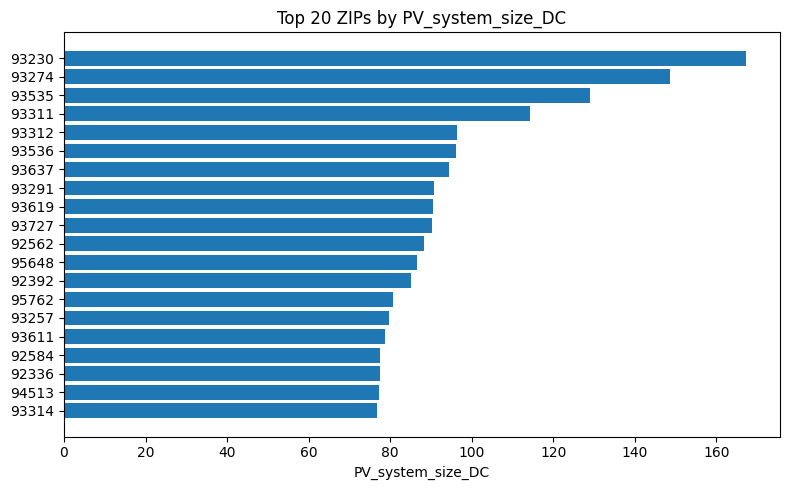

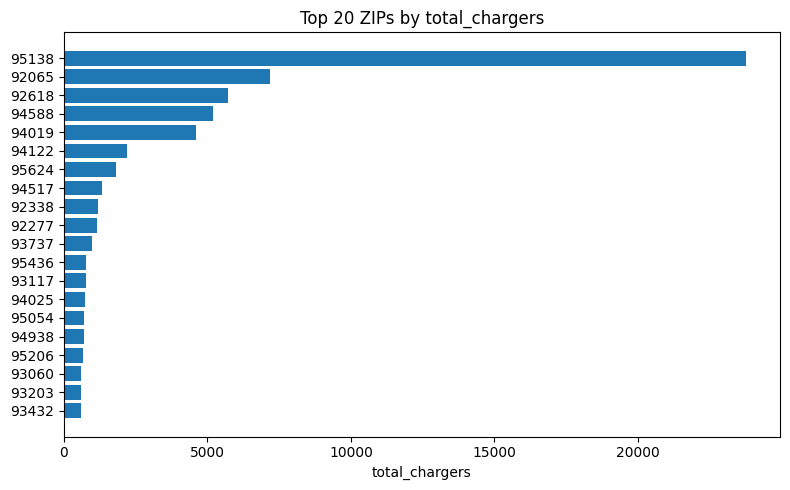

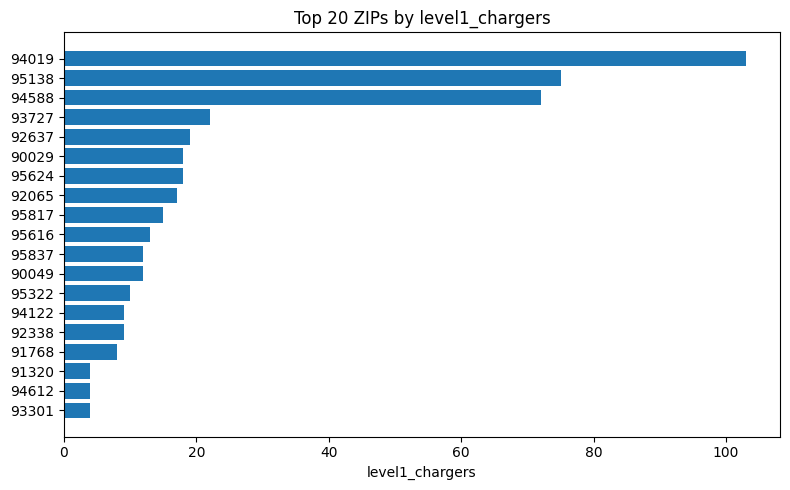

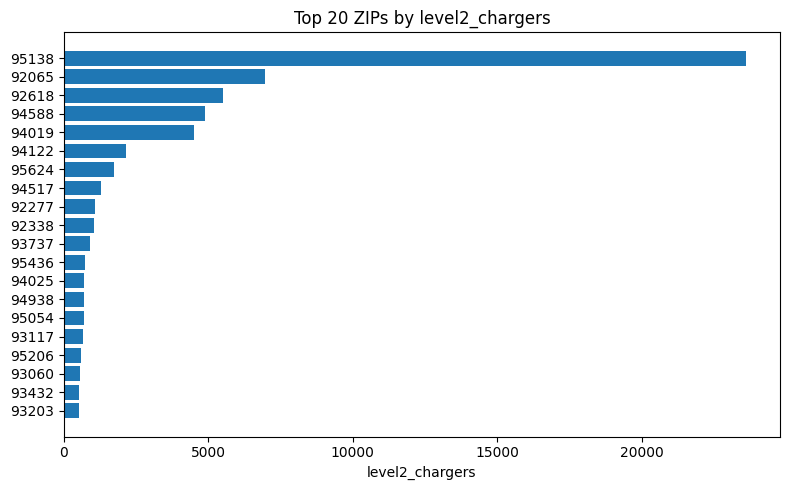

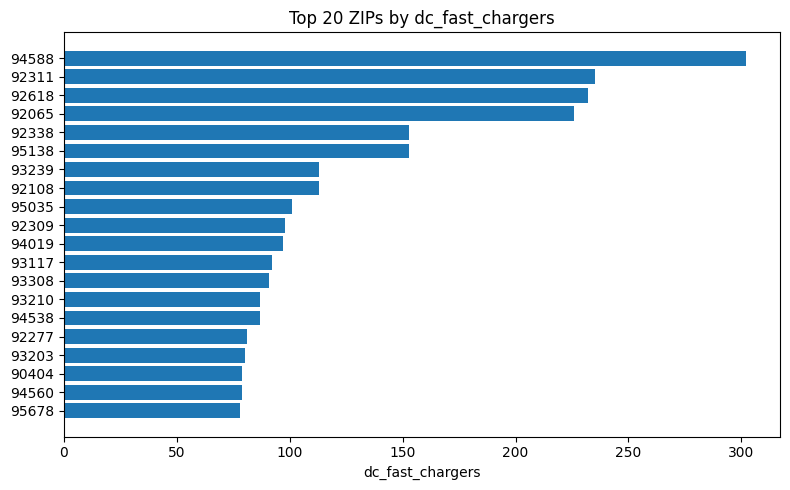

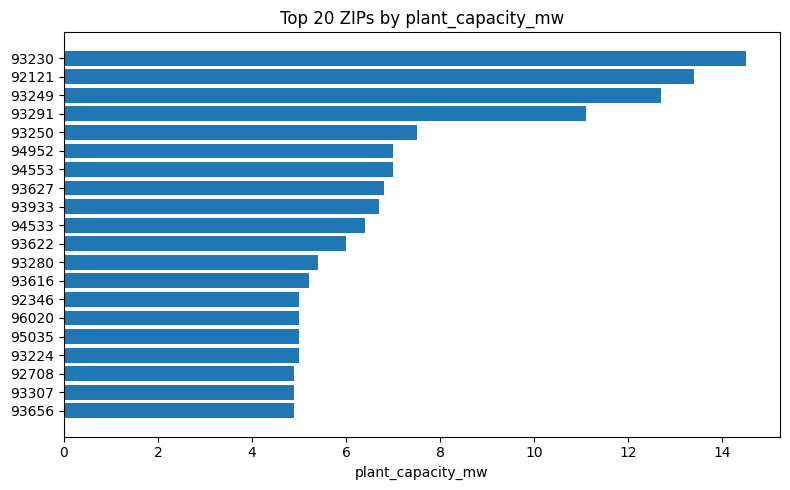

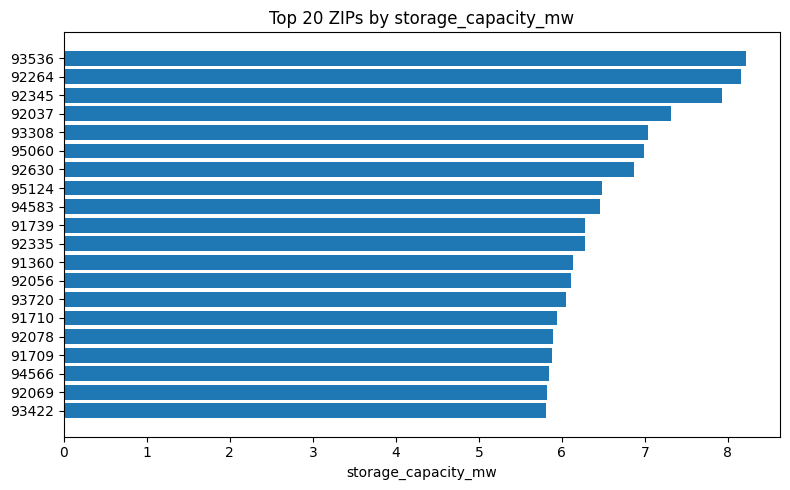

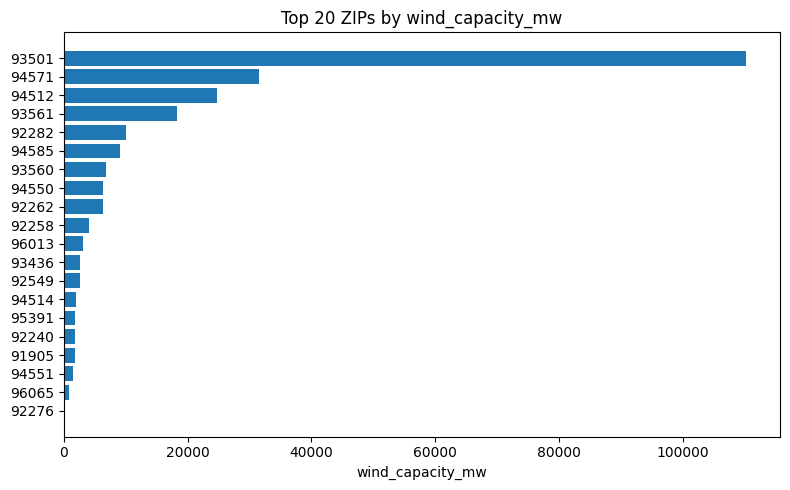

In [17]:
# -----------------------
# 3) Top ZIPs for each metric (outliers + sanity)
# -----------------------
def plot_top_n(d, col, n=20):
    """Plot the top-N ZIP codes by the specified metric.

    This is useful for sanity-checking extreme values and identifying which ZIPs
    dominate statewide totals for a given DER metric.

    Args:
        d: DataFrame containing `zip_code` and `col`.
        col: Metric column to rank by.
        n: Number of ZIPs to display.

    Returns:
        None. Displays a horizontal bar chart.
    """
    tmp = d[["zip_code", col]].copy()
    tmp = tmp.dropna()
    tmp = tmp.sort_values(col, ascending=False).head(n)
    plt.figure(figsize=(8, max(4, 0.25*n)))
    plt.barh(tmp["zip_code"].astype(int).astype(str), tmp[col].astype(float))
    plt.gca().invert_yaxis()
    plt.title(f"Top {n} ZIPs by {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

for c in COLS:
    plot_top_n(df0, c, n=20)

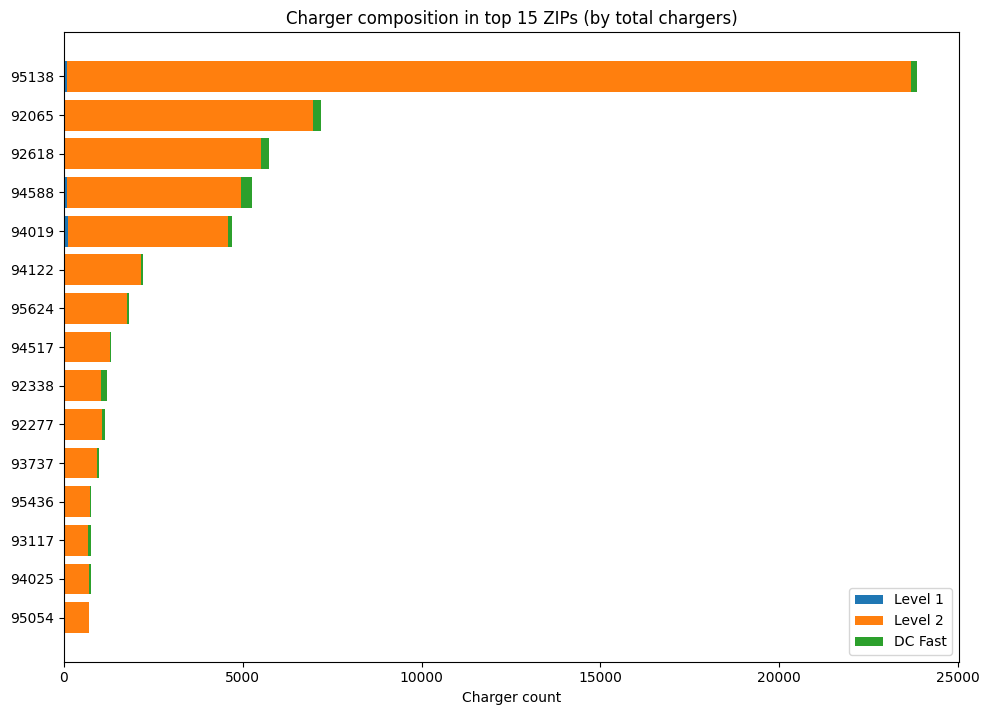

In [18]:
# -----------------------
# 4) Charger composition: stacked bars for top N ZIPs by total chargers
# -----------------------
def plot_charger_composition(d, n=15):
    """Plot stacked charger counts (L1/L2/DC fast) for the top-N ZIPs by total chargers.

    This helps separate whether high total-charger ZIPs are driven by Level 2
    deployments versus DC fast charging infrastructure.

    Args:
        d: DataFrame containing charger columns and `zip_code`.
        n: Number of top ZIPs (ranked by `total_chargers`) to include.

    Returns:
        None. Displays a stacked horizontal bar chart.
    """
    tmp = d[["zip_code","level1_chargers","level2_chargers","dc_fast_chargers","total_chargers"]].copy()
    tmp = tmp.sort_values("total_chargers", ascending=False).head(n)

    z = tmp["zip_code"].astype(int).astype(str).tolist()
    l1 = tmp["level1_chargers"].astype(float).values
    l2 = tmp["level2_chargers"].astype(float).values
    dc = tmp["dc_fast_chargers"].astype(float).values

    plt.figure(figsize=(10, 0.35*n + 2))
    plt.barh(z, l1, label="Level 1")
    plt.barh(z, l2, left=l1, label="Level 2")
    plt.barh(z, dc, left=l1+l2, label="DC Fast")
    plt.gca().invert_yaxis()
    plt.title(f"Charger composition in top {n} ZIPs (by total chargers)")
    plt.xlabel("Charger count")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_charger_composition(df0, n=15)

In [16]:
# -----------------------
# 5) Relationships (scatter + linear fit), using log1p to handle heavy skew
# -----------------------
def scatter_with_fit(d, x, y, logx=False, logy=True, title=None):
    """Scatterplot of y vs x with an overlaid linear fit, with optional log1p transforms.

    Designed for highly skewed outcomes (e.g., capacity/counts). By default it
    applies log1p to y to reduce the impact of extreme outliers; set `logx=True`
    to make log-log style plots.

    The transform used is log(1 + max(value, 0)) to avoid issues with negatives.

    Args:
        d: DataFrame containing columns `x` and `y`.
        x: X-axis column name.
        y: Y-axis column name.
        logx: If True, plot log(1 + clipped_nonnegative(x)).
        logy: If True, plot log(1 + clipped_nonnegative(y)).
        title: Optional plot title override.

    Returns:
        None. Displays the scatterplot.
    """
    tmp = d[[x, y]].dropna().copy()
    X = tmp[x].astype(float).values
    Y = tmp[y].astype(float).values

    if logx: Xp = np.log1p(np.clip(X, 0, None))
    else:    Xp = X
    if logy: Yp = np.log1p(np.clip(Y, 0, None))
    else:    Yp = Y

    plt.figure()
    plt.scatter(Xp, Yp, s=10)
    xlabel = f"log(1+{x})" if logx else x
    ylabel = f"log(1+{y})" if logy else y
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title or f"{ylabel} vs {xlabel}")

    if len(Xp) >= 2:
        m, b = np.polyfit(Xp, Yp, 1)
        xs = np.linspace(Xp.min(), Xp.max(), 200)
        plt.plot(xs, m*xs + b)

    plt.tight_layout()
    plt.show()

# Core “story” plots
scatter_with_fit(df0, "median_household_income", "PV_system_size_DC")  # if you later add income
scatter_with_fit(df0, "PV_system_size_DC", "total_chargers", logx=True, logy=True,
                 title="EV chargers vs PV (log-log)")

scatter_with_fit(df0, "PV_system_size_DC", "storage_capacity_mw", logx=True, logy=True,
                 title="Storage vs PV (log-log)")

scatter_with_fit(df0, "plant_capacity_mw", "PV_system_size_DC", logx=True, logy=True,
                 title="Utility-scale plant capacity vs PV (log-log)")

scatter_with_fit(df0, "wind_capacity_mw", "PV_system_size_DC", logx=True, logy=True,
                 title="Wind vs PV (log-log)")

KeyError: "['median_household_income'] not in index"

In [ ]:
# -----------------------
# 6) Simple “presence vs outcome” boxplots
# -----------------------
def boxplot_by_presence(d, outcome, presence_col, title=None):
    """Compare an outcome distribution by whether another metric is present (>0).

    Splits ZIPs into two groups: those with `presence_col` == 0 and those with
    `presence_col` > 0, then plots side-by-side boxplots of log1p(outcome).
    This is a quick way to check whether outcomes are systematically higher in
    ZIPs that have a given type of infrastructure.

    Args:
        d: DataFrame containing `outcome` and `presence_col`.
        outcome: The metric whose distribution you want to compare.
        presence_col: Column used to define presence (>0) vs absence (=0).
        title: Optional plot title override.

    Returns:
        None. Displays a boxplot (with outliers hidden).
    """
    tmp = d[[outcome, presence_col]].dropna().copy()
    present = tmp[presence_col].astype(float) > 0
    a = tmp.loc[~present, outcome].astype(float)
    b = tmp.loc[present,  outcome].astype(float)

    # log1p helps when extremely skewed
    a = np.log1p(np.clip(a, 0, None))
    b = np.log1p(np.clip(b, 0, None))

    plt.figure()
    plt.boxplot([a.values, b.values], labels=[f"{presence_col}=0", f"{presence_col}>0"], showfliers=False)
    plt.ylabel(f"log(1+{outcome})")
    plt.title(title or f"{outcome} by presence of {presence_col}")
    plt.tight_layout()
    plt.show()

boxplot_by_presence(df0, "PV_system_size_DC", "plant_capacity_mw", "PV vs presence of power plants")
boxplot_by_presence(df0, "PV_system_size_DC", "storage_capacity_mw", "PV vs presence of storage")
boxplot_by_presence(df0, "PV_system_size_DC", "wind_capacity_mw", "PV vs presence of wind")

In [ ]:
# -----------------------
# 7) Correlation heatmap (numeric only)
# -----------------------
def corr_heatmap(d, cols, title="Correlation heatmap"):
    """Plot a simple correlation heatmap for selected numeric columns.

    Useful for diagnosing redundancy/multicollinearity among DER metrics prior
    to modeling. Columns are coerced to numeric; non-numeric values become NaN.

    Args:
        d: DataFrame containing the specified columns.
        cols: List of column names to include in the correlation matrix.
        title: Plot title.

    Returns:
        None. Displays an image heatmap with a colorbar.
    """
    tmp = d[cols].apply(pd.to_numeric, errors="coerce")
    corr = tmp.corr()

    plt.figure(figsize=(0.6*len(cols) + 3, 0.6*len(cols) + 3))
    plt.imshow(corr.values, aspect="auto")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

corr_heatmap(df0, COLS, "Correlations among DER metrics (filled-0)")